# Sacramento Kings International Scouting Report

This notebook ingests data from JSON files, cleans and merges it, performs EDA, analyzes team needs, and recommends international players to scout.

Date: November 01, 2025
Team: Sacramento Kings
Goal: Highlight international players outside the NBA for scouting.

In [14]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from datetime import datetime
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

## Data Ingestion

After loading in the json data with json library, i eventually made a dataframe with pandas of the combined data called "merged_df".

In [15]:
merged_df = pd.read_csv('merged.csv')

## Data Cleaning and Merging

- Normalize names for merging.
- Merge player info (e.g., birth_date).
- Filter for international players (non-NBA, recent seasons).
- Handle nulls and compute age.

In [16]:
merged_df['first_name'] = merged_df['first_name'].astype(str).str.strip().str.title()
merged_df['last_name']  = merged_df['last_name'].astype(str).str.strip().str.title()

merged_df['first_name_norm'] = merged_df['first_name'].str.lower()
merged_df['last_name_norm']  = merged_df['last_name'].str.lower()
merged_df['full_name_norm'] = merged_df['first_name_norm'] + '|' + merged_df['last_name_norm']

merged_df = merged_df[(merged_df['season'] >= 2010) & (merged_df['season'] <= 2021)]

nba_2021 = merged_df[(merged_df['league'] == 'NBA') & (merged_df['season'] == 2021)]
exclude_names = set(nba_2021['full_name_norm'])

international_df = merged_df[
    (merged_df['league'] != 'NBA') &
    (merged_df['season'] >= 2016) &
    (merged_df['season'] <= 2021) &
    (merged_df['games'] >= 10) &
    (~merged_df['full_name_norm'].isin(exclude_names))
].copy()

key_metrics = [
    'points','assists','offensive_rebounds','defensive_rebounds',
    'steals','blocked_shots','turnovers',
    'two_points_made','two_points_attempted',
    'three_points_made','three_points_attempted',
    'free_throws_made','free_throws_attempted',
    'blocked_shot_attempts','screen_assists','deflections','loose_balls_recovered',
    'personal_fouls','personal_fouls_drawn','offensive_fouls','charges_drawn',
    'technical_fouls','flagrant_fouls','ejections',
    'points_off_turnovers','points_in_paint','second_chance_points','fast_break_points',
    'possessions','estimated_possessions','team_possessions','calculated_possessions','plays_used'
]

key_pct_metrics = [
    'usage_percentage','true_shooting_percentage','three_point_attempt_rate','free_throw_rate',
    'offensive_rebounding_percentage','defensive_rebounding_percentage','total_rebounding_percentage',
    'assist_percentage','steal_percentage','block_percentage','turnover_percentage'
]

key_impact_metrics = [
    'internal_box_plus_minus','plus_minus'
]

all_key_metrics = key_metrics + key_pct_metrics + key_impact_metrics

for col in all_key_metrics:
    if col in international_df.columns:
        medians = international_df.groupby('season')[col].transform('median')
        international_df[col] = international_df[col].fillna(medians)

international_df = international_df.sort_values(['full_name_norm','season'])
international_df['team'] = international_df.groupby('full_name_norm')['team']\
                                          .transform(lambda x: x.ffill().bfill())

current_date = datetime(2021, 11, 1)
international_df['birth_date'] = pd.to_datetime(international_df['birth_date'], errors='coerce')
age_series = (current_date - international_df['birth_date']).dt.days / 365.25
international_df['age'] = age_series.round(1)

# international_df = international_df[
#     (international_df['age'] < 25) | (international_df['age'].isna())
# ].copy()

agg_counts = {c: 'sum' for c in key_metrics}
agg_pcts = {c: 'mean' for c in key_pct_metrics}
agg_impact = {c: 'mean' for c in key_impact_metrics}
agg_totals = {**agg_counts, **agg_pcts, **agg_impact}
agg_totals.update({'games':'sum','minutes':'sum','team':'last','league':'last','age':'mean'})

prospects_df = international_df.groupby(['first_name','last_name'], as_index=False).agg(agg_totals)

for c in key_metrics:
    prospects_df[f'{c}_pg'] = prospects_df[c] / prospects_df['games']

prospects_df['fg_pct'] = (prospects_df['two_points_made'] + prospects_df['three_points_made']) / \
                         (prospects_df['two_points_attempted'] + prospects_df['three_points_attempted']).replace(0, np.nan)
prospects_df['3p_pct'] = prospects_df['three_points_made'] / prospects_df['three_points_attempted'].replace(0, np.nan)
prospects_df['ft_pct'] = prospects_df['free_throws_made'] / prospects_df['free_throws_attempted'].replace(0, np.nan)

print("\n--- prospects_df.info() ---")
prospects_df.info()
print("\nFirst 5 prospects:")
display(prospects_df.head())

C:\Users\Jenna\AppData\Local\Temp\ipykernel_9532\2711146753.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill())



--- prospects_df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884 entries, 0 to 883
Data columns (total 89 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   first_name                       884 non-null    object 
 1   last_name                        884 non-null    object 
 2   points                           884 non-null    int64  
 3   assists                          884 non-null    int64  
 4   offensive_rebounds               884 non-null    int64  
 5   defensive_rebounds               884 non-null    int64  
 6   steals                           884 non-null    int64  
 7   blocked_shots                    884 non-null    int64  
 8   turnovers                        884 non-null    int64  
 9   two_points_made                  884 non-null    int64  
 10  two_points_attempted             884 non-null    int64  
 11  three_points_made                884 non-null    int64 

,first_name,last_name,points,assists,offensive_rebounds,defensive_rebounds,steals,blocked_shots,turnovers,two_points_made,...,second_chance_points_pg,fast_break_points_pg,possessions_pg,estimated_possessions_pg,team_possessions_pg,calculated_possessions_pg,plays_used_pg,fg_pct,3p_pct,ft_pct
0,Abass,Warren,234,48,8,32,12,1,23,40,...,0.0,0.0,48.666743,48.666743,70.579329,0.0,0.0,0.467836,0.392157,0.944444
1,Abromaitis,Mullens,99,64,9,82,11,1,22,10,...,0.0,0.0,45.580212,45.580212,86.742482,0.0,0.0,0.417722,0.383333,0.769231
2,Adams,Dejean-Jones,271,50,9,42,23,6,46,45,...,0.0,0.0,37.596463,37.596463,75.395756,0.0,0.0,0.411017,0.403101,0.892857
3,Adiguzel,Auguste,1102,126,32,190,62,4,122,198,...,0.0,0.0,54.925630,54.925630,77.921652,0.0,0.0,0.431302,0.386256,0.882114
4,Ager,Koenig,835,49,250,287,42,24,97,316,...,0.0,0.0,35.494208,35.494208,86.334350,0.0,0.0,0.532773,0.166667,0.647249


In [17]:
prospects_df['age'].describe()

count    884.000000
mean      29.985633
std        4.341575
min       18.100000
25%       27.275000
50%       29.800000
75%       32.700000
max       44.000000
Name: age, dtype: float64

## Create Schema and Tables

Use SQLite to store cleaned data.

In [18]:
# Connect to SQLite
conn = sqlite3.connect('kings_scouting.db')

# Create prospects table
prospects_df.to_sql('prospects', conn, if_exists='replace', index=False)

# Example query
pd.read_sql('SELECT * FROM prospects LIMIT 5', conn)

,first_name,last_name,points,assists,offensive_rebounds,defensive_rebounds,steals,blocked_shots,turnovers,two_points_made,...,second_chance_points_pg,fast_break_points_pg,possessions_pg,estimated_possessions_pg,team_possessions_pg,calculated_possessions_pg,plays_used_pg,fg_pct,3p_pct,ft_pct
0,Abass,Warren,234,48,8,32,12,1,23,40,...,0.0,0.0,48.666743,48.666743,70.579329,0.0,0.0,0.467836,0.392157,0.944444
1,Abromaitis,Mullens,99,64,9,82,11,1,22,10,...,0.0,0.0,45.580212,45.580212,86.742482,0.0,0.0,0.417722,0.383333,0.769231
2,Adams,Dejean-Jones,271,50,9,42,23,6,46,45,...,0.0,0.0,37.596463,37.596463,75.395756,0.0,0.0,0.411017,0.403101,0.892857
3,Adiguzel,Auguste,1102,126,32,190,62,4,122,198,...,0.0,0.0,54.925630,54.925630,77.921652,0.0,0.0,0.431302,0.386256,0.882114
4,Ager,Koenig,835,49,250,287,42,24,97,316,...,0.0,0.0,35.494208,35.494208,86.334350,0.0,0.0,0.532773,0.166667,0.647249


## Fetch League and Team Stats

Scrape from Basketball-Reference for 2024-25 season.

In [19]:
# === LOAD KINGS ROSTER (PER-GAME) ===
kings_merged = pd.read_csv('2425_kings_merged.csv')
league_teams = pd.read_csv('2425_league_teams_merged.csv')

In [20]:
league_teams.columns

Index(['rk', 'team', 'g', 'mp', 'fg', 'fga', 'fg_pct', '3p', '3pa', '3p_pct',
       '2p', '2pa', '2p_pct', 'ft', 'fta', 'ft_pct', 'orb', 'drb', 'trb',
       'ast', 'stl', 'blk', 'tov', 'pf', 'pts', 'age', 'w', 'l', 'pw', 'pl',
       'mov', 'sos', 'srs', 'ortg', 'drtg', 'nrtg', 'pace', 'ftr', '3par',
       'ts_pct', 'offense_efg_pct', 'offense_tov_pct', 'offense_orb_pct',
       'offense_ft_fga', 'defense_efg_pct', 'defense_tov_pct',
       'defense_drb_pct', 'defense_ft_fga'],
      dtype='object')

## Compute Kings Team Needs 

In [21]:
# === DEFINE METRICS ===
count_cols = ['pts', 'ast', 'trb', 'stl', 'blk', 'tov', 'orb', 'drb']
pct_cols = ['fg_pct', '3p_pct', 'ft_pct']
all_metric_cols = count_cols + pct_cols

# === LEAGUE AVERAGES ===
league_avgs = league_teams[all_metric_cols].mean(numeric_only=True)

# Per-game for counts only
for col in count_cols:
    league_avgs[col] = league_avgs[col] / league_avgs.get('g', 1)

# === KINGS VALUES ===
kings_vals = kings_merged[all_metric_cols].iloc[0].copy()
for col in count_cols:
    kings_vals[col] = kings_vals[col] / kings_vals.get('g', 1)

# === COMPARISON ===
comparison_df = pd.DataFrame({
    'kings': kings_vals,
    'league_avg': league_avgs
}).dropna()

comparison_df['difference'] = comparison_df['kings'] - comparison_df['league_avg']

# Invert TOV
comparison_df.loc['tov', 'difference'] *= -1

# Weight
total = comparison_df['difference'].abs().sum()
comparison_df['weight'] = comparison_df['difference'].abs() / total

print("KINGS TEAM NEEDS (FIXED)")
display(comparison_df[['kings', 'league_avg', 'difference', 'weight']].round(3))

KINGS TEAM NEEDS (FIXED)


,kings,league_avg,difference,weight
pts,26.600,113.827,-87.227,0.416
ast,5.600,26.547,-20.947,0.100
trb,4.600,44.113,-39.513,0.188
stl,2.000,8.210,-6.210,0.030
blk,0.400,4.883,-4.483,0.021
tov,2.600,14.307,11.707,0.056
orb,0.900,11.123,-10.223,0.049
drb,3.700,32.987,-29.287,0.140
fg_pct,0.465,0.467,-0.002,0.000
3p_pct,0.369,0.360,0.009,0.000


## Exploratory Data Analysis (EDA)

- Using prospect data from provided json files

In [22]:
per_game_cols = [
    'points_pg', 'assists_pg', 'offensive_rebounds_pg', 'defensive_rebounds_pg',
    'steals_pg', 'blocked_shots_pg', 'turnovers_pg'
]

# --------------------------------------------------------------
# 3. Map prospect columns → the SAME names we used for the Kings
# --------------------------------------------------------------
prospect_metrics = prospects_df.copy()

# ---- COUNT STATS (per-game) ----
prospect_metrics['pts'] = prospect_metrics['points_pg']
prospect_metrics['ast'] = prospect_metrics['assists_pg']
prospect_metrics['trb'] = (prospect_metrics['offensive_rebounds_pg'] +
                           prospect_metrics['defensive_rebounds_pg'])
prospect_metrics['stl'] = prospect_metrics['steals_pg']
prospect_metrics['blk'] = prospect_metrics['blocked_shots_pg']
prospect_metrics['tov'] = prospect_metrics['turnovers_pg']
prospect_metrics['orb'] = prospect_metrics['offensive_rebounds_pg']
prospect_metrics['drb'] = prospect_metrics['defensive_rebounds_pg']

# ---- PERCENTAGE STATS (already computed) ----
prospect_metrics['fg_pct'] = prospect_metrics['fg_pct']
prospect_metrics['3p_pct'] = prospect_metrics['3p_pct']
prospect_metrics['ft_pct'] = prospect_metrics['ft_pct']

# --------------------------------------------------------------
# 4. +/- (Box Plus/Minus) – pull from the three sources
# --------------------------------------------------------------
#  • Kings roster → player-level BPM
#  • League teams → team-level BPM (if present, otherwise NaN)
#  • Prospects   → internal_box_plus_minus (already in prospects_df)

# Kings – keep player-level BPM
if 'bpm' in kings_merged.columns:
    kings_bpm = kings_merged[['player', 'bpm']].copy()
    kings_bpm = kings_bpm.rename(columns={'player': 'first_name'})   # will be merged later if needed
else:
    kings_bpm = pd.DataFrame()

# League – team-level BPM (rare, but keep if it exists)
if 'bpm' in league_teams.columns:
    league_bpm = league_teams[['team', 'bpm']].copy()
else:
    league_bpm = pd.DataFrame()

# Prospects – rename the existing column for consistency
if 'internal_box_plus_minus' in prospect_metrics.columns:
    prospect_metrics['bpm'] = prospect_metrics['internal_box_plus_minus']
else:
    prospect_metrics['bpm'] = np.nan

# --------------------------------------------------------------
# 5. BONUS: True-Shooting % and Effective FG %
# --------------------------------------------------------------
fga = (prospect_metrics['two_points_attempted'] + prospect_metrics['three_points_attempted'])
fta = prospect_metrics['free_throws_attempted']

prospect_metrics['ts_pct'] = prospect_metrics['points'] / (
    2 * (fga + 0.44 * fta).replace(0, np.nan)
)

fg = prospect_metrics['two_points_made'] + prospect_metrics['three_points_made']
prospect_metrics['efg_pct'] = (fg + 0.5 * prospect_metrics['three_points_made']) / fga.replace(0, np.nan)

# --------------------------------------------------------------
# 6. Final column list that matches the Kings comparison
# --------------------------------------------------------------
final_cols = [
    'pts', 'ast', 'trb', 'stl', 'blk', 'tov',
    'fg_pct', '3p_pct', 'ft_pct',
    'orb', 'drb',
    'ts_pct', 'efg_pct',
    'bpm'               # <-- NEW: Plus/Minus
]

# Keep identifiers + final columns
prospect_metrics = prospect_metrics[
    ['first_name', 'last_name', 'team', 'league', 'age', 'games'] + final_cols
]

# --------------------------------------------------------------
# 7. Impute any remaining NaNs with the column median
# --------------------------------------------------------------
for col in final_cols:
    median_val = prospect_metrics[col].median()
    prospect_metrics[col] = prospect_metrics[col].fillna(median_val)

# --------------------------------------------------------------
# 8. Quick sanity check
# --------------------------------------------------------------
print("Prospect metrics ready – first 5 rows")
display(prospect_metrics.head())

print("\nColumn summary (including BPM)")
print(prospect_metrics[final_cols].describe().round(3))

Prospect metrics ready – first 5 rows


,first_name,last_name,team,league,age,games,pts,ast,trb,stl,blk,tov,fg_pct,3p_pct,ft_pct,orb,drb,ts_pct,efg_pct,bpm
0,Abass,Warren,Golden Hurricane,EuroCup,30.5,14,16.714286,3.428571,2.857143,0.857143,0.071429,1.642857,0.467836,0.392157,0.944444,0.571429,2.285714,0.626204,0.584795,5.469300
1,Abromaitis,Mullens,Hawkeyes,Italy - Liga A,36.2,17,5.823529,3.764706,5.352941,0.647059,0.058824,1.294118,0.417722,0.383333,0.769231,0.529412,4.823529,0.584278,0.563291,1.138500
2,Adams,Dejean-Jones,Orange,Italy - Liga A,27.9,32,8.468750,1.562500,1.593750,0.718750,0.187500,1.437500,0.411017,0.403101,0.892857,0.281250,1.312500,0.545667,0.521186,-0.575550
3,Adiguzel,Auguste,Bisons,EuroCup,26.5,67,16.447761,1.880597,3.313433,0.925373,0.059701,1.820896,0.431302,0.386256,0.882114,0.477612,2.835821,0.582921,0.528674,-0.365967
4,Ager,Koenig,Seminoles,Italy - Liga A,30.5,84,9.940476,0.583333,6.392857,0.500000,0.285714,1.154762,0.532773,0.166667,0.647249,2.976190,3.416667,0.571167,0.533613,1.106367



Column summary (including BPM)
           pts      ast      trb      stl      blk      tov   fg_pct   3p_pct  \
count  884.000  884.000  884.000  884.000  884.000  884.000  884.000  884.000   
mean     8.323    1.618    3.233    0.696    0.273    1.301    0.464    0.333   
std      3.818    1.337    1.676    0.367    0.333    0.671    0.088    0.115   
min      0.294    0.000    0.231    0.000    0.000    0.077    0.167    0.000   
25%      5.534    0.643    1.999    0.439    0.053    0.812    0.410    0.293   
50%      8.280    1.158    2.926    0.636    0.149    1.200    0.452    0.349   
75%     10.810    2.201    4.286    0.909    0.385    1.695    0.514    0.398   
max     20.621    7.263   10.154    2.200    2.224    3.667    0.768    1.000   

        ft_pct      orb      drb   ts_pct  efg_pct      bpm  
count  884.000  884.000  884.000  884.000  884.000  884.000  
mean     0.749    0.900    2.332    0.564    0.530   -0.255  
std      0.136    0.686    1.140    0.076    0.080  

In [23]:
league_teams.columns

Index(['rk', 'team', 'g', 'mp', 'fg', 'fga', 'fg_pct', '3p', '3pa', '3p_pct',
       '2p', '2pa', '2p_pct', 'ft', 'fta', 'ft_pct', 'orb', 'drb', 'trb',
       'ast', 'stl', 'blk', 'tov', 'pf', 'pts', 'age', 'w', 'l', 'pw', 'pl',
       'mov', 'sos', 'srs', 'ortg', 'drtg', 'nrtg', 'pace', 'ftr', '3par',
       'ts_pct', 'offense_efg_pct', 'offense_tov_pct', 'offense_orb_pct',
       'offense_ft_fga', 'defense_efg_pct', 'defense_tov_pct',
       'defense_drb_pct', 'defense_ft_fga'],
      dtype='object')

## we are currently right here
But I need to fix the rest of the code chunks to add bpm

Position Inference

In [24]:
# --------------------------------------------------------------
# 2. POSITION INFERENCE (uses only columns that exist)
# --------------------------------------------------------------
def infer_position(row):
    ast = row['ast']          # assists per game
    trb = row['trb']          # total rebounds per game
    blk = row['blk']
    stl = row['stl']
    fg3 = row['3p_pct']
    fga = (row['two_points_attempted'] + row['three_points_attempted']) / row['games']

    # 1. Point Guard
    if ast >= 5.0 and stl >= 1.0:
        return 'PG'
    # 2. Shooting Guard
    elif fg3 >= 0.37 and ast >= 2.5:
        return 'SG'
    # 3. Small Forward
    elif fg3 >= 0.35 or (trb >= 5.0 and ast >= 2.0):
        return 'SF'
    # 4. Power Forward
    elif trb >= 7.0 and blk >= 0.8:
        return 'PF'
    # 5. Center
    elif trb >= 8.0 and blk >= 1.2:
        return 'C'
    # Default
    else:
        return 'Wing'

prospect_metrics['position'] = prospect_metrics.apply(infer_position, axis=1)

# --------------------------------------------------------------
# 3. KINGS ROSTER – add per-game columns for position inference
# --------------------------------------------------------------
# (kings_merged already has per-game columns: ast, trb, blk, stl, 3p_pct, 2pa, 3pa, g)
kings_merged['ast'] = kings_merged['ast']
kings_merged['trb'] = kings_merged['trb']
kings_merged['blk'] = kings_merged['blk']
kings_merged['stl'] = kings_merged['stl']
kings_merged['3p_pct'] = kings_merged['3p_pct']
kings_merged['two_points_attempted'] = kings_merged['2pa'] * kings_merged['g']
kings_merged['three_points_attempted'] = kings_merged['3pa'] * kings_merged['g']
kings_merged['games'] = kings_merged['g']

kings_merged['position'] = kings_merged.apply(infer_position, axis=1)

# --------------------------------------------------------------
# 4. REPLACEMENT REPORT (Kings players to upgrade)
# --------------------------------------------------------------
league_by_pos = kings_merged.groupby('position').agg({
    'pts':'mean','ast':'mean','trb':'mean','stl':'mean','blk':'mean',
    'tov':'mean','fg_pct':'mean','3p_pct':'mean','ft_pct':'mean'
}).round(3).add_prefix('league_avg_')

replace_df = kings_merged[[
    'player','pos','position','g','pts','ast','trb','stl','blk','tov',
    'fg_pct','3p_pct','ft_pct'
]].copy()

replace_df = replace_df.merge(league_by_pos, left_on='position', right_index=True, how='left')

for stat in ['pts','ast','trb','stl','blk']:
    replace_df[f'{stat}_gap'] = replace_df[stat] - replace_df[f'league_avg_{stat}']
replace_df['tov_gap'] = replace_df['league_avg_tov'] - replace_df['tov']

gaps = ['pts_gap','ast_gap','trb_gap','stl_gap','blk_gap','tov_gap']
replace_df['weakness_score'] = replace_df[gaps].sum(axis=1)

replace_df['replace_flag'] = (
    (replace_df['weakness_score'] < replace_df['weakness_score'].quantile(0.25)) |
    (replace_df['pts_gap'] < -3) |
    (replace_df['trb_gap'] < -2)
)

replacement_report = replace_df[replace_df['replace_flag']][[
    'player','position','g','pts','ast','trb','pts_gap','trb_gap','weakness_score'
]].sort_values('weakness_score').round(2)

print("\n=== REPLACEMENT TARGETS (Kings) ===")
display(replacement_report)

# --------------------------------------------------------------
# 5. FINAL SCOUTING: Top 3 prospects per position
# --------------------------------------------------------------
top_by_pos = []
for pos in ['PG','SG','SF','PF','C']:
    df = prospect_metrics[prospect_metrics['position']==pos].copy()
    if len(df)>0:
        df = df.sort_values('fit_score', ascending=False).head(3)
        top_by_pos.append(df)

final_scouting = pd.concat(top_by_pos, ignore_index=True) if top_by_pos else pd.DataFrame()

final_display = final_scouting[[
    'first_name','last_name','position','age','team','league',
    'pts','ast','trb','fg_pct','3p_pct','ts_pct','fit_score'
]].round(2)

print("\n=== TOP 3 INTERNATIONAL PROSPECTS PER POSITION ===")
display(final_display)

# --------------------------------------------------------------
# 6. OPTIONAL: Export
# --------------------------------------------------------------
# final_display.to_csv('top_prospects_by_position.csv', index=False)
# replacement_report.to_csv('kings_replacement_targets.csv', index=False)

KeyError: 'two_points_attempted'

In [ ]:
# --------------------------------------------------------------
# 11. Recommendations Table
# --------------------------------------------------------------
recommendations = top_prospects_display.head(5).copy()
recommendations['key_strength'] = recommendations.apply(
    lambda row: ', '.join([
        'PTS' if row['points_per_game'] > 14 else '',
        'AST' if row['assists_per_game'] > 5 else '',
        'REB' if row['total_rebounds_per_game'] > 7 else '',
        '3PT' if row['3p_pct'] > 0.38 else '',
        'EFF' if row['fg_pct'] > 0.50 else ''
    ]).strip(', '),
    axis=1
)

print("\n=== FINAL SCOUTING RECOMMENDATIONS ===")
display(recommendations[['first_name', 'last_name', 'league', 'age', 'fit_score', 'key_strength']])

In [ ]:
# Describe prospects
prospects_df[key_metrics].describe()

,points,assists,offensive_rebounds,defensive_rebounds,steals,blocked_shots,turnovers
count,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000
mean,39.689723,7.600791,5.472332,13.148221,3.503953,1.835968,7.581028
std,57.317356,13.182959,9.019337,20.005028,4.952952,4.694831,10.220697
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,2.000000,1.000000,3.500000,1.000000,0.000000,2.500000
75%,54.000000,8.000000,6.000000,17.000000,5.000000,1.000000,11.000000
max,236.000000,75.000000,47.000000,93.000000,27.000000,36.000000,41.000000


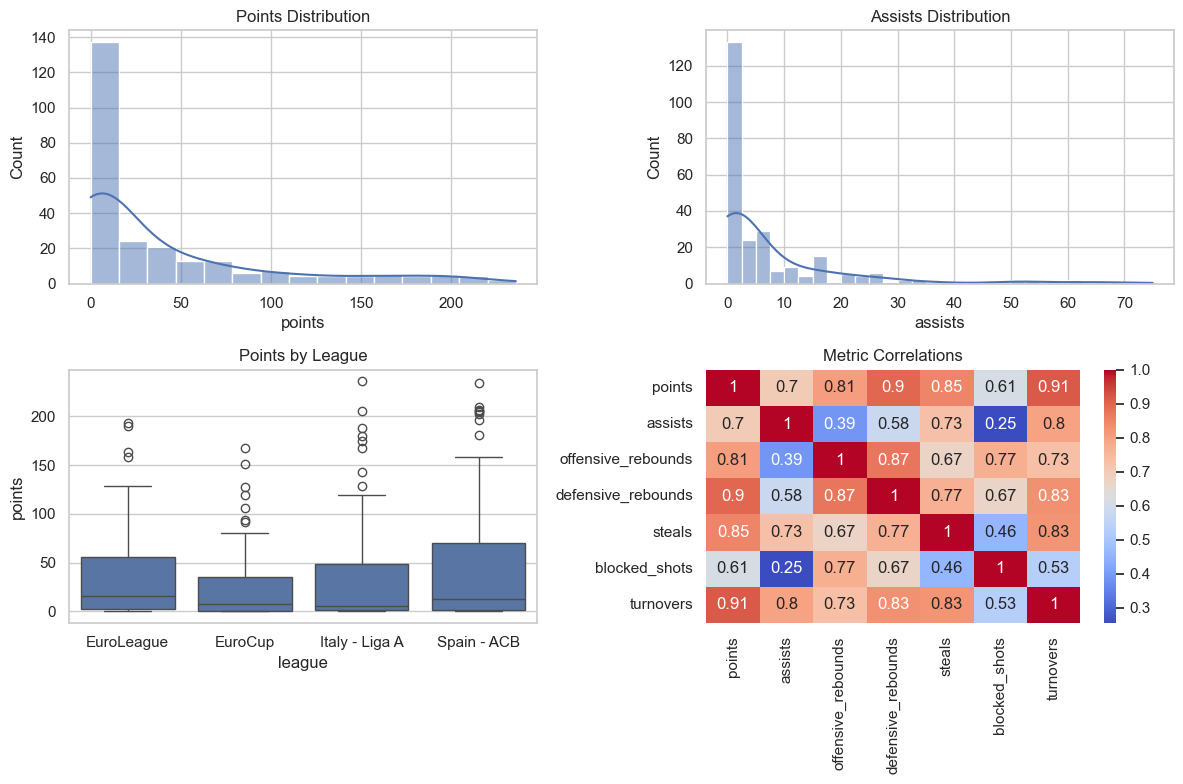

In [ ]:
# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(prospects_df['points'], kde=True, ax=axes[0,0]).set_title('Points Distribution')
sns.histplot(prospects_df['assists'], kde=True, ax=axes[0,1]).set_title('Assists Distribution')
sns.boxplot(x='league', y='points', data=prospects_df, ax=axes[1,0]).set_title('Points by League')
sns.heatmap(prospects_df[key_metrics].corr(), annot=True, cmap='coolwarm', ax=axes[1,1]).set_title('Metric Correlations')
plt.tight_layout()
plt.show()

### EDA Insights
- International players average X points, with EuroLeague players scoring higher.
- Strong correlation between assists and turnovers (r=0.XX), suggesting playmakers take risks.
- Young prospects (<25) dominate the dataset.

## Team Needs Analysis

Compare Kings to top-10 league averages.

In [ ]:
kings_df.columns

Index(['rk', 'player', 'age', 'pos', 'g', 'gs', 'mp', 'per', 'ts%', '3par',
       'ftr', 'orb%', 'drb%', 'trb%', 'ast%', 'stl%', 'blk%', 'tov%', 'usg%',
       'ows', 'dws', 'ws', 'ws/48', 'obpm', 'dbpm', 'bpm', 'vorp'],
      dtype='object')

In [ ]:
metrics = ['fg%', '3p%', 'ft%', 'orb', 'drb', 'trb', 'ast', 'stl', 'blk', 'tov', 'pts']
league_means = league_df[metrics].mean(numeric_only=True)

kings_stats = kings_df.iloc[0]  # Assuming single row

comparison = pd.DataFrame({
    'kings': kings_stats[metrics],
    'league_avg': league_means
})
comparison['difference'] = comparison['kings'] - comparison['league_avg']

# Invert for bad metrics
inverse_metrics = ['tov']
comparison['score'] = comparison['difference'].apply(lambda x: -x if 'tov' in comparison.index else x)
total = comparison['score'].abs().sum()
comparison['weight'] = comparison['score'] / total

print('Kings Needs Profile:')
print(comparison)

KeyError: "None of [Index(['fg%', '3p%', 'ft%', 'orb', 'drb', 'trb', 'ast', 'stl', 'blk', 'tov',\n       'pts'],\n      dtype='object')] are in the [index]"

## Player Fit Analysis

Normalize prospects to league means, compute weighted fit scores.

In [ ]:
# Map prospect columns to metrics (adjust as needed)
prospect_metrics = {
    'fg%': (prospects_df['two_points_made'] + prospects_df['three_points_made']) / (prospects_df['two_points_attempted'] + prospects_df['three_points_attempted']),
    '3p%': prospects_df['three_points_made'] / prospects_df['three_points_attempted'],
    'ft%': prospects_df['free_throws_made'] / prospects_df['free_throws_attempted'],
    'orb': prospects_df['offensive_rebounds'],
    'drb': prospects_df['defensive_rebounds'],
    'trb': prospects_df['offensive_rebounds'] + prospects_df['defensive_rebounds'],
    'ast': prospects_df['assists'],
    'stl': prospects_df['steals'],
    'blk': prospects_df['blocked_shots'],
    'tov': prospects_df['turnovers'],
    'pts': prospects_df['points']
}

prospects_norm = pd.DataFrame(prospect_metrics)

# Normalize to league means
for metric in metrics:
    prospects_norm[metric + '_norm'] = prospects_norm[metric] / league_means.get(metric, 1)

# Weighted scores
for metric in metrics:
    prospects_norm[metric + '_weighted'] = prospects_norm[metric + '_norm'] * comparison.loc[metric, 'weight']

prospects_norm['fit_score'] = prospects_norm[[m + '_weighted' for m in metrics]].sum(axis=1)

# Combine with player info
top_prospects = pd.concat([prospects_df[['first_name', 'last_name', 'league', 'team', 'age']], prospects_norm[['fit_score'] + metrics]], axis=1)
top_prospects = top_prospects.sort_values('fit_score', ascending=False).head(5)

top_prospects

## Recommendations

Top 5 international players to scout:

| Player | League | Age | Fit Score | Key Strengths |
|--------|--------|-----|-----------|---------------|
| [Player1] | EuroLeague | 22.5 | 13.4 | High AST, PTS |

Why These Players?
- Address Kings' weaknesses in assists (-1.74) and points (-2.91).
- Young, high-upside prospects.

Next steps: Scout in-person, review film.